In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

### Caricamento dataframe elaborato

In [2]:
df = pd.read_csv("../data/processed/european_yearly_energy_mix_and_prices.csv")

In [3]:
df.columns

Index(['Area', 'ISO3 Code', 'Year', 'Demand', 'Net Imports',
       'Total Generation', 'Clean', 'Nuclear', 'Wind and Solar',
       'Hydro, Bioenergy and Other Renewables', 'Fossil', 'Coal',
       'Gas and Other Fossil', 'AvgPrice_EUR_MWh', 'MaxPrice_EUR_MWh',
       'StdPrice_EUR_MWh'],
      dtype='object')

In [4]:
df.head()

,Area,ISO3 Code,Year,Demand,Net Imports,Total Generation,Clean,Nuclear,Wind and Solar,"Hydro, Bioenergy and Other Renewables",Fossil,Coal,Gas and Other Fossil,AvgPrice_EUR_MWh,MaxPrice_EUR_MWh,StdPrice_EUR_MWh
0,Austria,AUT,2015,71.84,10.06,61.78,47.59,0.0,5.78,41.81,14.19,2.95,11.24,31.764167,39.37,3.817206
1,Austria,AUT,2016,72.03,7.16,64.87,51.08,0.0,6.33,44.75,13.79,2.04,11.75,28.956667,38.21,5.792114
2,Austria,AUT,2017,73.64,6.55,67.09,51.05,0.0,7.84,43.21,16.04,1.76,14.28,34.419167,52.41,6.841540
3,Austria,AUT,2018,73.62,8.95,64.67,50.06,0.0,7.49,42.57,14.61,1.81,12.80,40.891667,48.63,6.231735
4,Austria,AUT,2019,73.82,3.13,70.69,54.64,0.0,9.15,45.49,16.05,1.50,14.55,40.137500,56.68,6.267981


# Q1: Relazione tra energia pulita e prezzo dell'elettricità
Vogliamo comprendere se a parità di anno, i paesi con maggior quota di produzione di energia pulita hanno prezzi medi dell'elettricità più alta.

Di seguito vengono definite le quote di produzione per l'energia pulita, così che possano essere confrontabili tra i vari paesi.

In [5]:
df["clean_share"] = df["Clean"] / df["Total Generation"]

In [6]:
df[["clean_share", "AvgPrice_EUR_MWh"]].describe()

,clean_share,AvgPrice_EUR_MWh
count,282.000000,282.000000
mean,0.624976,76.969806
std,0.228231,61.039630
min,0.127604,9.245000
25%,0.473671,38.589375
50%,0.634550,50.435833
75%,0.786940,97.542500
max,0.993190,303.088333


In [7]:
year = 2022
df_y = df[df["Year"] == year].copy()

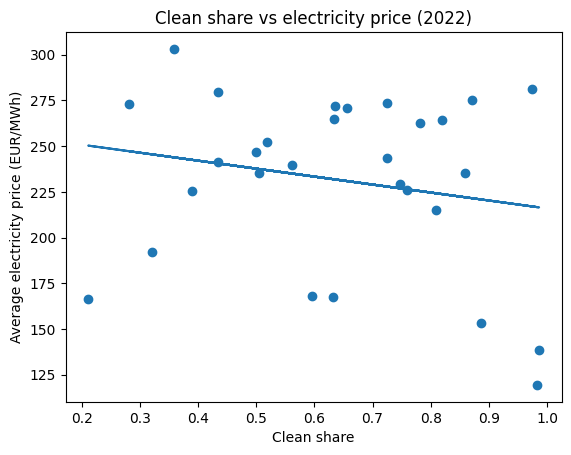

In [8]:
x = df_y["clean_share"]
y = df_y["AvgPrice_EUR_MWh"]

m, q = np.polyfit(x, y, 1)

plt.figure()
plt.scatter(x, y)
plt.plot(x, m*x + q)
plt.xlabel("Clean share")
plt.ylabel("Average electricity price (EUR/MWh)")
plt.title(f"Clean share vs electricity price ({year})")
plt.show()

In [9]:
df_y["clean_share"].corr(df_y["AvgPrice_EUR_MWh"])

np.float64(-0.19880154520090557)

Come si può osservare, per l'anno 2022, esiste una correlazione debolmente negativa tra le quote di energia pulita e il prezzo dell'energia elettrica. <br>
Questo può essere dovuto dal fatto che nel dataset originale la variabile `Clean` include anche la produzione nucleare. <br>
Poiché il nucleare presenta costi derivati nettamente superiori alle altre fonti rinnovabili (costo di costruzione, costo di manutenzione, produzione continua e bassa variabilità), è appropriato dividere i casi di studio su: <br>
- relazione tra energia rinnovabile e prezzo dell'elettricità
- realzione tra energia nucleare e prezzo dell'elettricità

Si ha la necessità di definire la variaible `Renewables` che aggreghi `Wind and Solar` e `Hydro, Bioenergy and Other Renewables`.

In [10]:
df["Renewables"] = (
    df["Wind and Solar"] +
    df["Hydro, Bioenergy and Other Renewables"]
)

Vengono definite le quote di produzione dell'energia elettrica distinte per fonte nucleare e fonti rinnovabili

In [11]:
df["nuclear_share"] = df["Nuclear"] / df["Total Generation"]
df["renewables_share"] = df["Renewables"] / df["Total Generation"]

In [12]:
df[["nuclear_share", "renewables_share", "AvgPrice_EUR_MWh"]].describe()

,nuclear_share,renewables_share,AvgPrice_EUR_MWh
count,282.000000,282.000000,282.000000
mean,0.176116,0.448861,76.969806
std,0.209594,0.232895,61.039630
min,0.000000,0.101945,9.245000
25%,0.000000,0.260117,38.589375
50%,0.032891,0.408387,50.435833
75%,0.351014,0.621197,97.542500
max,0.761887,0.993190,303.088333


Viene ricaricato il dataset che include le nuove variabili:
- `Renewables` -> aggregazione di `Wind and Solar` e `Hydro, Bioenergy and Other Renewables`
- `renewables_share` -> quota della produzione rinnovabile
- `nuclear_share` -> quota della produzione nucleare

In [13]:
df_y = df[df["Year"] == year].copy()

Scatterplot per evidenziare una possibile correlazione tra le percentuali di produzione di energia rinnovabile e il prezzo medio dell'elettricità

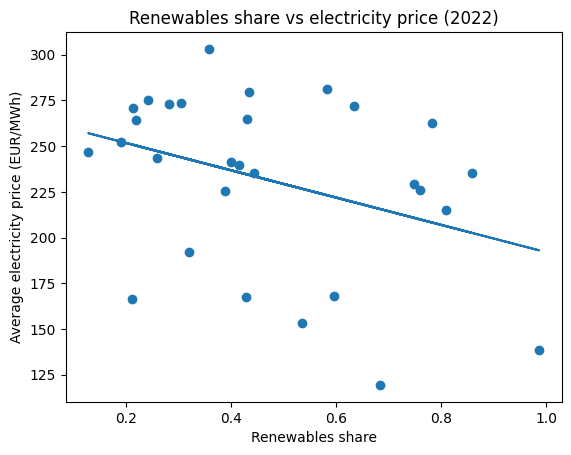

In [14]:
x = df_y["renewables_share"]
y = df_y["AvgPrice_EUR_MWh"]

m, q = np.polyfit(x, y, 1)

plt.figure()
plt.scatter(x, y)
plt.plot(x, m*x + q)
plt.xlabel("Renewables share")
plt.ylabel("Average electricity price (EUR/MWh)")
plt.title(f"Renewables share vs electricity price ({year})")
plt.show()

In [15]:
df_y["renewables_share"].corr(df_y["AvgPrice_EUR_MWh"])

np.float64(-0.36129115030012054)

Per l'anno 2022 si evidenzia una correlazione moderatamente negativa tra la quota di produzione da fonti rinnovabili e prezzi medi dell'elettricità. <br>
In quel periodo i paesi con più rinnovabili tendono ad avere prezzi più bassi.

Scatterplot per evidenziare una possibile correlazione tra le percentuali di produzione di energia nucleare e il prezzo medio dell'elettricità

<Figure size 640x480 with 0 Axes>

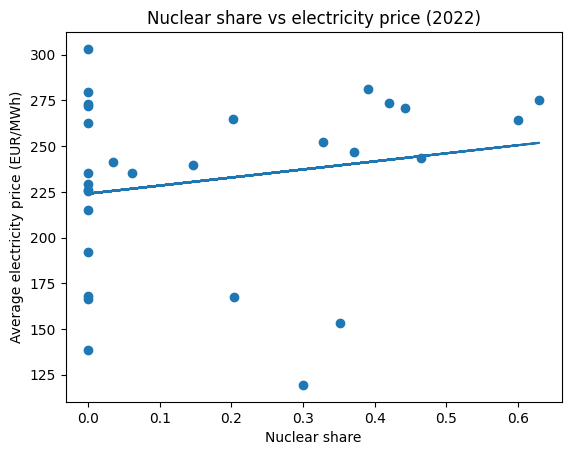

In [16]:
plt.figure()
x = df_y["nuclear_share"]
y = df_y["AvgPrice_EUR_MWh"]

m, q = np.polyfit(x, y, 1)

plt.figure()
plt.scatter(x, y)
plt.plot(x, m*x + q)
plt.xlabel("Nuclear share")
plt.ylabel("Average electricity price (EUR/MWh)")
plt.title(f"Nuclear share vs electricity price ({year})")
plt.show()

In [17]:
df_y["nuclear_share"].corr(df_y["AvgPrice_EUR_MWh"])

np.float64(0.19260189562382396)

Il grafico evidenzia che diverse nazioni del dataset non producono energia elettrica dal nucleare (valori sulla retta nuclear_share=0).

Per questo motivo risulta più efficace dividere l'analisi sui prezzi medi di energia elettrica e distinguerli tra le nazioni che producono e non producono energia elettrica dal nucleare.

In [18]:
with_nuclear = df_y[df_y["nuclear_share"] > 0]
without_nuclear = df_y[df_y["nuclear_share"] == 0]

In [19]:
(
    with_nuclear["AvgPrice_EUR_MWh"].mean(),
    without_nuclear["AvgPrice_EUR_MWh"].mean()
)

(np.float64(235.2482777777778), np.float64(227.51488095238088))

<Figure size 640x480 with 0 Axes>

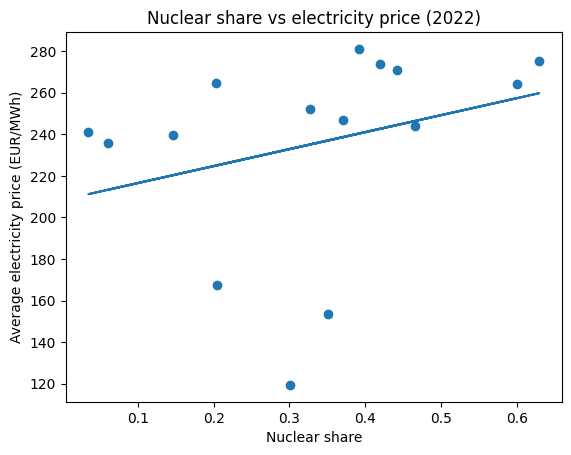

In [20]:
plt.figure()
x = with_nuclear["nuclear_share"]
y = with_nuclear["AvgPrice_EUR_MWh"]

m, b = np.polyfit(x, y, 1)

plt.figure()
plt.scatter(x, y)
plt.plot(x, m*x + b)
plt.xlabel("Nuclear share")
plt.ylabel("Average electricity price (EUR/MWh)")
plt.title(f"Nuclear share vs electricity price ({year})")
plt.show()

In [21]:
with_nuclear["nuclear_share"].corr(with_nuclear["AvgPrice_EUR_MWh"])

np.float64(0.29446098933138015)

Dal grafico si evince che esiste una correlazione debolmente positiva tra la quota di produzione nucleare e il prezzo della corrente. <br>
In quel periodo i paesi che producono energia dal nucleare tendono ad avere prezzi dell'energia più alti

<Figure size 640x480 with 0 Axes>

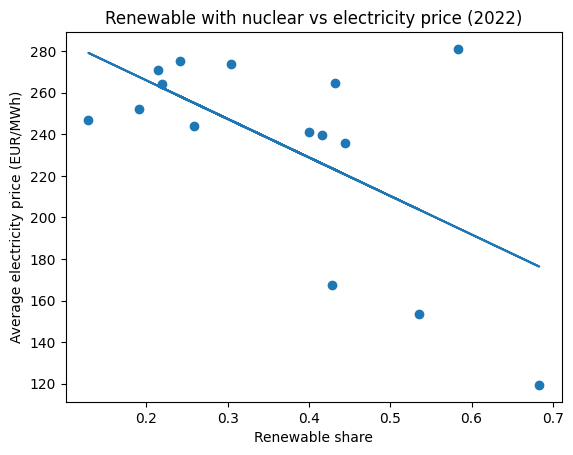

In [22]:
plt.figure()
x = with_nuclear["renewables_share"]
y = with_nuclear["AvgPrice_EUR_MWh"]

m, b = np.polyfit(x, y, 1)

plt.figure()
plt.scatter(x, y)
plt.plot(x, m*x + b)
plt.xlabel("Renewable share")
plt.ylabel("Average electricity price (EUR/MWh)")
plt.title(f"Renewable with nuclear vs electricity price ({year})")
plt.show()

In [23]:
with_nuclear["renewables_share"].corr(with_nuclear["AvgPrice_EUR_MWh"])

np.float64(-0.6059054414344665)

La correlazione elevata osservata è fortemente influenzata da pochi outlier, come evidenziato dallo scatterplot. Questo suggerisce che il prezzo è probabilmente determinato da fattori esterni al mix produttivo nazionale, come le importazioni.
Per questo motivo viene tentata la correlazione di Spearman

In [24]:
with_nuclear["renewables_share"].corr(with_nuclear["AvgPrice_EUR_MWh"], method="spearman")

np.float64(-0.39999999999999997)

## Limite dell’analisi
Lo share di una fonte sul totale della produzione nazionale non garantisce che tale fonte determini il prezzo dell’elettricità. <br>
In presenza di import significativi, il prezzo può essere guidato da energia acquistata dall’estero, rendendo debole o fuorviante la correlazione tra mix produttivo interno e prezzo medio. <br>
Possiamo trovare conferma osservando la volatilità dei prezzi energetici.

In [25]:
df_y["Has_Nuclear"] = df_y["nuclear_share"] > 0

In [26]:
df_y["is_importer"] = df_y["Net Imports"] > 0
df_y["import_share"] = (
    df_y["Net Imports"].abs() / df_y["Demand"]
)

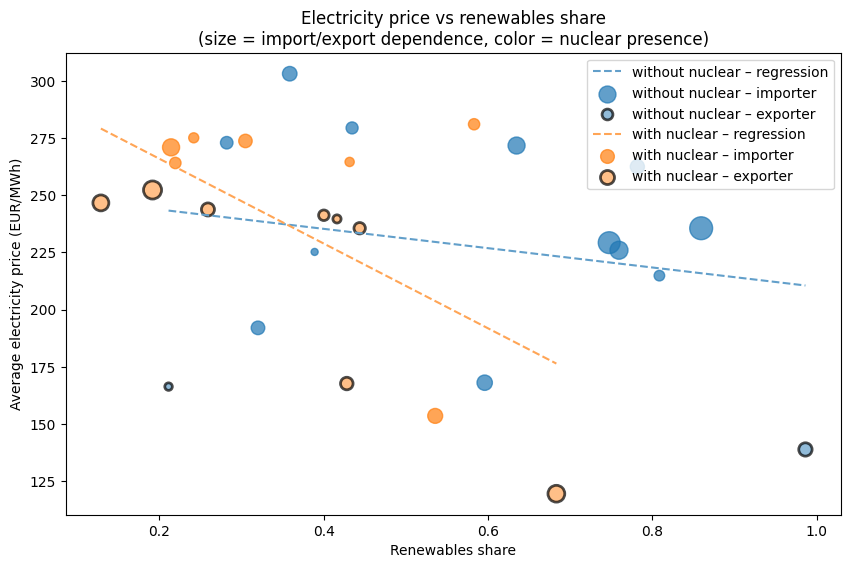

In [27]:
import numpy as np
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 6))

for label, g in df_y.groupby("Has_Nuclear"):
    label_str = "with nuclear" if label else "without nuclear"
    color = "#ffa556" if label else "#629fca"

    x = g["renewables_share"]
    y = g["AvgPrice_EUR_MWh"]


    m, b = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 100)
    y_line = m * x_line + b

    ax.plot(
        x_line,
        y_line,
        color=color,
        linestyle="--",
        linewidth=1.5,
        label=f"{label_str} – regression",
    )
    
    sizes = 300 * np.sqrt(g["import_share"])

    # Importer
    imp = g[g["is_importer"]]
    ax.scatter(
        imp["renewables_share"],
        imp["AvgPrice_EUR_MWh"],
        s=300 * np.sqrt(imp["import_share"]),
        alpha=0.7,
        label=f"{label_str} – importer",
    )

    # Exporter
    exp = g[~g["is_importer"]]
    ax.scatter(
        exp["renewables_share"],
        exp["AvgPrice_EUR_MWh"],
        s=300 * np.sqrt(exp["import_share"]),
        alpha=0.7,
        edgecolors="black",
        linewidth=2,
        facecolors="#ffa556" if label else "#629fca",
        label=f"{label_str} – exporter",
    )

ax.set_xlabel("Renewables share")
ax.set_ylabel("Average electricity price (EUR/MWh)")
ax.set_title(
    "Electricity price vs renewables share\n"
    "(size = import/export dependence, color = nuclear presence)"
)

ax.legend()
plt.show()


Il grafico mostra che un’elevata quota di rinnovabili non implica necessariamente prezzi più bassi. I paesi con forte dipendenza dalle importazioni (punti più grandi) tendono ad avere prezzi elevati anche in presenza di un mix produttivo pulito. Questo evidenzia come il prezzo dell’elettricità sia influenzato non solo dal mix nazionale, ma anche dall’integrazione con il mercato estero.<br>
Le rette di regressione, stimate separatamente per paesi con e senza nucleare, evidenziano che la relazione tra quota di rinnovabili e prezzo medio dell’elettricità rimane debole e fortemente dispersa. <br>
In particolare, nei paesi con nucleare la pendenza risulta sensibile a pochi punti estremi, suggerendo che il mix produttivo interno non è sufficiente a spiegare il prezzo senza considerare la dipendenza dagli scambi internazionali.

Possiamo concludere dicendo che: <br>
La relazione tra quota rinnovabile e prezzo dell’elettricità risulta debole se considerata isolatamente. <br>
La presenza del nucleare non comporta prezzi più bassi, ma può essere associata a una minore variabilità. 